In [ ]:

import json

path = "/Users/inuit/.cache/kagglehub/datasets/ambityga/imagenet100/versions/8/Labels.json"

with open(path, "r", encoding="utf-8") as f:
    labels_dir = json.load(f)

# 100 classes are expected from imagenet100
print(f"Loaded {len(labels_dir)} entries into labels_dir")

Loaded 100 entries into labels_dir


dict_keys(['n01968897', 'n01770081', 'n01818515', 'n02011460', 'n01496331', 'n01847000', 'n01687978', 'n01740131', 'n01537544', 'n01491361', 'n02007558', 'n01735189', 'n01630670', 'n01440764', 'n01819313', 'n02002556', 'n01667778', 'n01755581', 'n01924916', 'n01751748', 'n01984695', 'n01729977', 'n01614925', 'n01608432', 'n01443537', 'n01770393', 'n01855672', 'n01560419', 'n01592084', 'n01914609', 'n01582220', 'n01667114', 'n01985128', 'n01820546', 'n01773797', 'n02006656', 'n01986214', 'n01484850', 'n01749939', 'n01828970', 'n02018795', 'n01695060', 'n01729322', 'n01677366', 'n01734418', 'n01843383', 'n01806143', 'n01773549', 'n01775062', 'n01728572', 'n01601694', 'n01978287', 'n01930112', 'n01739381', 'n01883070', 'n01774384', 'n02037110', 'n01795545', 'n02027492', 'n01531178', 'n01944390', 'n01494475', 'n01632458', 'n01698640', 'n01675722', 'n01877812', 'n01622779', 'n01910747', 'n01860187', 'n01796340', 'n01833805', 'n01685808', 'n01756291', 'n01514859', 'n01753488', 'n02058221', '

In [71]:
import os
from glob import glob
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

training_data = "/Users/inuit/.cache/kagglehub/datasets/ambityga/imagenet100/train/"

# find class folders in training_data that match keys in labels_dir
available_classes = sorted(
    [d for d in os.listdir(training_data)
     if os.path.isdir(os.path.join(training_data, d)) and d in labels_dir]
)

assert len(available_classes) == len(labels_dir), "Mismatch between available class folders and labels_dir entries"

labels_to_idx = {wnid: idx for idx, wnid in enumerate(labels_dir.keys())}

images = []
labels = []

for keys, values in labels_to_idx.items():
    #files = [os.listdir(os.path.join(training_data, keys))]
    files = os.listdir(os.path.join(training_data, keys))    
    for file in files:
        file_path = os.path.join(training_data, keys, file)
        if os.path.isfile(file_path):
            images.append(file_path)
            labels.append(values)

assert len(images) == len(labels), "Mismatch between number of images and labels"


# simple image transforms suitable for a training pipeline
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

class ImageNet100Dataset(Dataset):
    def __init__(self, images, transform=None, labels=None):
        self.images = images
        self.transform = transform
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)
        #wnid = os.path.basename(os.path.dirname(img_path))  # folder name is the wnid
        label = self.labels[idx]
        return img, label

# create dataset + dataloader
dataset = ImageNet100Dataset(images[:512], transform=transform, labels=labels[:512])  # 
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)

# quick sanity check: fetch one batch
batch_imgs, batch_labels = next(iter(dataloader)) 
print(batch_imgs.shape, batch_labels.shape)


torch.Size([32, 3, 224, 224]) torch.Size([32])


Matplotlib is building the font cache; this may take a moment.


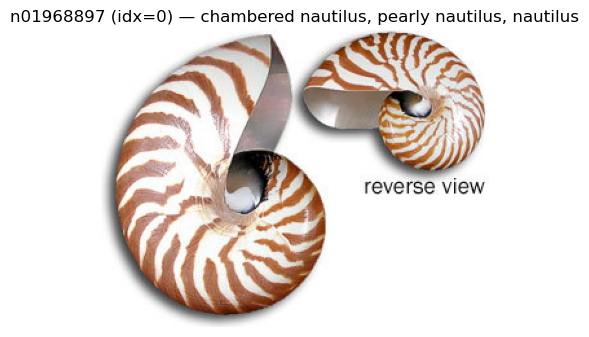

path: /Users/inuit/.cache/kagglehub/datasets/ambityga/imagenet100/train/n01968897/n01968897_6229.JPEG
label_idx: 0
wnid: n01968897
human_label: chambered nautilus, pearly nautilus, nautilus


In [72]:
import numpy as np

import matplotlib.pyplot as plt

# Path and label for the first sample
img_path = images[0]
label_idx = labels[0]

# invert labels_to_idx to get wnid from index
idx_to_wnid = {v: k for k, v in labels_to_idx.items()}
wnid = idx_to_wnid[label_idx]
human_label = labels_dir.get(wnid, wnid)

# load and display image
img = Image.open(img_path).convert("RGB")
plt.figure(figsize=(5, 5))
plt.imshow(np.array(img))
plt.axis("off")
plt.title(f"{wnid} (idx={label_idx}) — {human_label}")
plt.show()

# print details
print("path:", img_path)
print("label_idx:", label_idx)
print("wnid:", wnid)
print("human_label:", human_label)